<a href="https://colab.research.google.com/github/saim9211/skin_classification/blob/main/skin_image_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [111]:
import os
import zipfile
import shutil
import torch
import matplotlib.pyplot as plt

from google.colab import files
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [112]:
# Progress Bar
from tqdm import tqdm

# Visualization
import seaborn as sns

time to load the data

In [113]:
##device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## First i Upload the dataset in to my google drive then i download the dataset in to collab by this piece of script

In [114]:
# Install gdown for downloading from Google Drive
!pip install -qqq gdown

import os
import gdown

# Google Drive URL for the zip file
drive_url = "https://drive.google.com/file/d/1VwEw8HMu1XLQlCy2_2L5JrzaSmVDqqFO/view?usp=sharing"
# Define the local path where the zip file will be saved
local_zip_path = "/content/chest_xray.zip"

# Download the file using gdown
try:
    gdown.download(drive_url, local_zip_path, fuzzy=True)
    print(f"File downloaded to: {local_zip_path}")
    # Update zip_path to the local path for further operations
    zip_path = local_zip_path
    print("Local file exists after download:", os.path.exists(zip_path))
except Exception as e:
    print(f"Error downloading file: {e}")
    print("Please ensure the Google Drive link is correct and publicly accessible, or you might need to authenticate.")



Downloading...
From (original): https://drive.google.com/uc?id=1VwEw8HMu1XLQlCy2_2L5JrzaSmVDqqFO
From (redirected): https://drive.google.com/uc?id=1VwEw8HMu1XLQlCy2_2L5JrzaSmVDqqFO&confirm=t&uuid=4b8de06d-5242-4450-9e85-6d2561daee4f
To: /content/chest_xray.zip
100%|██████████| 1.05G/1.05G [00:18<00:00, 58.2MB/s]


File downloaded to: /content/chest_xray.zip
Local file exists after download: True


In [115]:
import zipfile
import os

zip_path = "/content/chest_xray.zip"
extract_path = "/content/chest_xray"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [116]:
print(os.listdir(extract_path))

['chest_xray']


In [117]:
dataset_dir = "/content/chest_xray/chest_xray"

In [118]:
dataset_dir

'/content/chest_xray/chest_xray'

In [119]:
train_dir = "/content/chest_xray/chest_xray/train"
test_dir = "/content/chest_xray/chest_xray/test"

# loading image

In [120]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [121]:
train_tranform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

test_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [122]:
from torchvision.datasets import ImageFolder
train_dataset=ImageFolder(train_dir,transform=train_tranform)
test_dataset=ImageFolder(test_dir,transform=test_transform)

In [123]:
print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Classes:", train_dataset.classes)
print("Mapping:", train_dataset.class_to_idx)
print("Train_images",train_dataset[0][0].shape)
print("Test_images",test_dataset[0][0].shape)

Train images: 2698
Test images: 468
Classes: ['NORMAL', 'PNEUMONIA']
Mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Train_images torch.Size([3, 224, 224])
Test_images torch.Size([3, 224, 224])


In [124]:
from torch.utils.data import DataLoader
train_dataloader=DataLoader(train_dataset,
                            batch_size=32,
                            shuffle=True,
                            pin_memory=True,
                            num_workers=1)
test_dataloader=DataLoader(test_dataset,
                           batch_size=32,
                           shuffle=True,
                           pin_memory=True,
                           num_workers=1)


In [125]:
print(f"Train batches: {len(train_dataloader)} | Test batches: {len(test_dataloader)}")

Train batches: 85 | Test batches: 15


In [126]:
img,label=next(iter(train_dataloader))
print(img.shape)
print(label.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


# Eda Process

## check the data distribution

In [127]:
from collections import Counter

train_counts = Counter(train_dataset.targets)
test_counts = Counter(test_dataset.targets)

print("TRAIN DISTRIBUTION")
for idx, count in train_counts.items():
    print(train_dataset.classes[idx], ":", count)

print("\nTEST DISTRIBUTION")
for idx, count in test_counts.items():
    print(test_dataset.classes[idx], ":", count)

TRAIN DISTRIBUTION
NORMAL : 1349
PNEUMONIA : 1349

TEST DISTRIBUTION
NORMAL : 234
PNEUMONIA : 234


##visualize the data

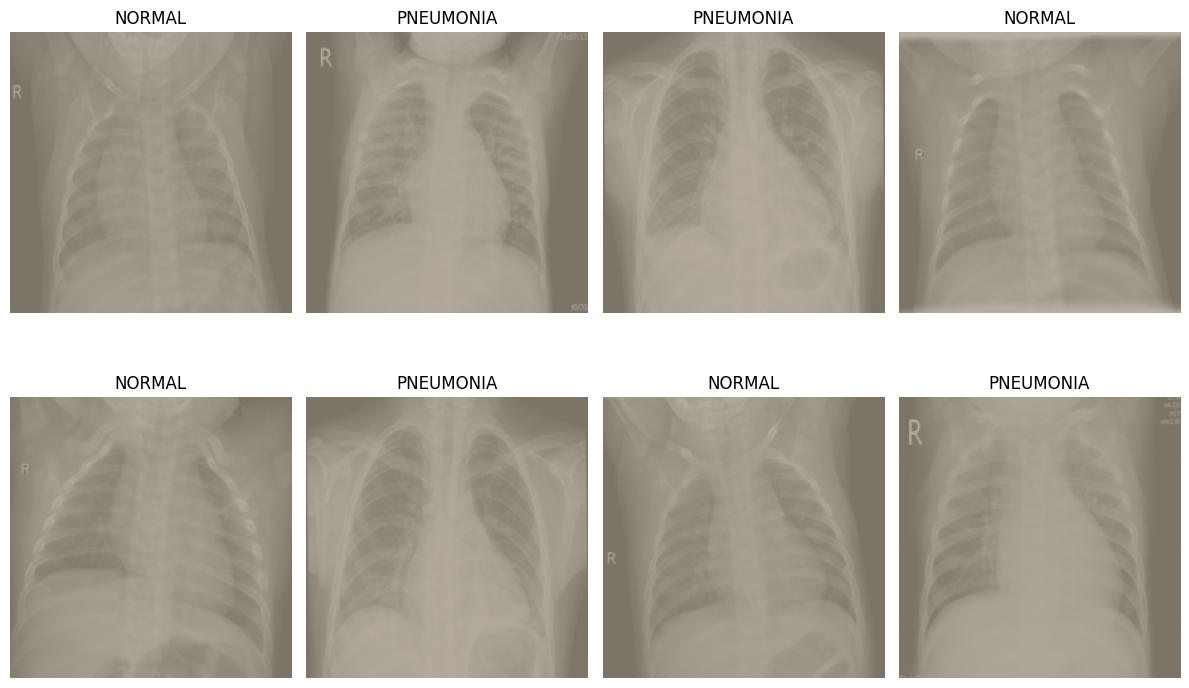

In [128]:
import matplotlib.pyplot as plt
import numpy as np

img, labels = next(iter(train_dataloader))

plt.figure(figsize=(12, 8))

for i in range(8):
    image = img[i].permute(1, 2, 0)

    # Undo normalization
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    image = image * std + mean
    image = image.clamp(0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## checking the size of the images

In [129]:
from PIL import Image
import os

sample_count = 20

for i, (path, label) in enumerate(train_dataset.samples[:sample_count]):

    try:
        img = Image.open(path)

        print(
            f"{i+1}. "
            f"{os.path.basename(path)} | "
            f"Size: {img.size} | "
            f"Mode: {img.mode} | "
            f"Class: {train_dataset.classes[label]}"
        )

    except Exception as e:
        print("ERROR:", path, e)

1. NORMAL-1003233-0001.jpeg | Size: (2572, 2476) | Mode: L | Class: NORMAL
2. NORMAL-1012843-0001.jpeg | Size: (1982, 1751) | Mode: L | Class: NORMAL
3. NORMAL-1014768-0001.jpeg | Size: (1236, 1013) | Mode: L | Class: NORMAL
4. NORMAL-1023731-0001.jpeg | Size: (1414, 1206) | Mode: L | Class: NORMAL
5. NORMAL-1029510-0001.jpeg | Size: (1786, 1449) | Mode: L | Class: NORMAL
6. NORMAL-1031320-0001.jpeg | Size: (1646, 1395) | Mode: L | Class: NORMAL
7. NORMAL-1034239-0001.jpeg | Size: (1550, 1075) | Mode: L | Class: NORMAL
8. NORMAL-1041364-0001.jpeg | Size: (1684, 1240) | Mode: L | Class: NORMAL
9. NORMAL-1044645-0001.jpeg | Size: (1534, 1187) | Mode: L | Class: NORMAL
10. NORMAL-1055663-0001.jpeg | Size: (1632, 1225) | Mode: L | Class: NORMAL
11. NORMAL-1063934-0001.jpeg | Size: (1466, 1265) | Mode: L | Class: NORMAL
12. NORMAL-1064313-0001.jpeg | Size: (1746, 1442) | Mode: L | Class: NORMAL
13. NORMAL-1064313-0002.jpeg | Size: (1604, 1248) | Mode: L | Class: NORMAL
14. NORMAL-1068231-00

## checking the corrupted file

In [130]:
from PIL import Image

def check_corrupted(dataset):

    corrupted = []

    for path, label in dataset.samples:

        try:
            img = Image.open(path)
            img.verify()

        except Exception:
            corrupted.append(path)

    return corrupted


train_corrupted = check_corrupted(train_dataset)
test_corrupted = check_corrupted(test_dataset)

print("Corrupted train images:", len(train_corrupted))
print("Corrupted test images:", len(test_corrupted))

Corrupted train images: 0
Corrupted test images: 0


# dividing the data in to train/val/test split  train 80% -> train 60 and 20 val and remaining 20 to test

In [131]:
from torch.utils.data import random_split, DataLoader

# 80% training, 20% validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Test images:", len(test_dataset))

Training images: 2158
Validation images: 540
Test images: 468


## dataloader for it

In [132]:
train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

##class imbalance check

In [133]:
import torch
from collections import Counter

train_labels = [
    train_dataset.targets[i]
    for i in train_subset.indices
]

class_counts = Counter(train_labels)

print("Training class distribution:")

for class_id, count in class_counts.items():
    print(
        train_dataset.classes[class_id],
        ":",
        count
    )

Training class distribution:
NORMAL : 1077
PNEUMONIA : 1081


In [134]:
num_classes = len(train_dataset.classes)
total_samples = len(train_labels)

class_weights = []

for class_id in range(num_classes):

    count = class_counts[class_id]

    weight = total_samples / (
        num_classes * count
    )

    class_weights.append(weight)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Class weights:", class_weights)

Class weights: tensor([1.0019, 0.9981])


# training and testing model

In [135]:
import  torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [136]:
weights=torchvision.models.ResNet18_Weights.DEFAULT
model=torchvision.models.resnet18(weights=weights)

In [137]:
!pip install torchinfo

In [138]:
# Print a summary using torchinfo (uncomment for actual output)
from torchinfo import summary
summary(model=model,
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 1000]           --                   True
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   9,408                True
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   128                  True
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   True
│    └─BasicBlock (0)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   True
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     36,864               True
│    │    └─BatchN

 freezing the base line

In [139]:
for param in model.parameters():
  param.requires_grad = False


In [140]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
out_dt=len(class_counts)
model.classifier=nn.Sequential(
    nn.Dropout(p=0.2,inplace=True),
    nn.Linear(in_features=512,out_features=out_dt),
    nn.Softmax(dim=1)
)


In [142]:
# # Do a summary *after* freezing the features and changing the output classifier layer (uncomment for actual output)
summary(model,
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 1000]           1,026                Partial
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   (9,408)              False
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   (128)                False
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   False
│    └─BasicBlock (0)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   False
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     (36,864)             False
│    │    

## creating the training step function

In [144]:
from tqdm.auto import tqdm
def train_step(model, dataloader, loss_fn, optimizer, device):
  train_loss,train_acc=0,0

  for X,y in tqdm(dataloader):
    X,Y=X.to(device),y.to(device)

    y_pred=model(X)

    loss=loss_fn(y_pred,y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    train_loss+=loss.item()

    # Calculate predictions
    predicted = torch.argmax(y_pred, dim=1)

    # Calculate correct predictions
    train_acc += (predicted == y).sum().item()

    train_total += y.size(0)


    train_loss=train_loss/len(dataloader)
    train_acc=train_acc/ train_total
    return train_loss,train_acc



In [145]:
from tqdm.auto import tqdm
def test_Step(
    model,
    dataloader,
    optimizer,
    loss_fn,
    eval,):
  test_loss,test_acc=0,0

  for X,y in tqdm(dataloader):
    X,y=X.to(device),y.to(device)

    pred=model(X)
    loss=loss_fn(pred,y)
    test_loss+=loss.item()

    # Calculate predictions
    predicted = torch.argmax(pred, dim=1)

    # Calculate correct predictions
    test_acc += (predicted == y).sum().item()

    test_total += y.size(0)

    # Average loss
    test_loss = test_loss / len(dataloader)

    # Accuracy
    test_accuracy = test_correct / test_total

    return test_loss, test_accuracy
